<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões tangenciais em vigas

### Problema 2

A figura representa uma viga de secção retangular com parede fina, onde foi soldada uma barra ABC. No ponto A estão aplicadas três forças, paralelas aos eixos $x$, $y$ e $z$ e com os sentidos indicados.

**a)** Sabendo que $R=$ 10 kN e $P=$ 1 kN, determine qual o valor máximo da força $Q$ para que a tensão normal na secção DEF não ultrapasse $\sigma_\mathrm{adm}$ = 150 MPa.

**b)** Para o valor de $Q$ obtido na alínea anterior, determine a distribuição de tensões normais na secção DEF, com a posição do eixo neutro e os valores máximo e mínimo da tensão $\sigma_{xx}$.

**c)** Calcule o tensor das tensões no ponto H referido ao sistema de eixos $xyz$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P2/MSII_Au06_P2.png"
width="600">

### Resolução

#### **a)** Sabendo que $R=$ 10 kN e $P=$ 1 kN, determine qual o valor máximo da força $Q$ para que a tensão normal na secção DEF não ultrapasse $\sigma_\mathrm{adm}$ = 150 MPa.

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass
d = varin()
d.tub_b = 60.*1e-3  # unit: m
d.tub_h = 40.*1e-3 # unit: m
d.tub_e = 4.*1e-3 # unit: m
d.xCF = 800.e-3 # unit: m
d.zAB = 100.e-3 # unit: m
d.zHE = 15.e-3 # unit: m
d.Pz = 1.*1e3 # unit: N/m
d.Rx = 10.*1e3 # unit: N/m
d.Sadm = 150.e6 # unit: Pa

####  Sistema de força-binário equivalente ($N, M_y, M_z$)

- Diagrama de corpo livre

Considere-se um troço da viga, seccionada a uma distância de 800 mm da face de referência. Pelo princípio de Saint-Venant, pode substituir-se o carregamento original (carga excêntrica) por um carregamento equivalente (carga centrada + momentos) sempre que se pretender determinar a distribuição de tensões numa secção S suficientemente afastada das extremidades da barra. Os esforços internos na secção S a 800 mm do bordo livre: $N,V_z,V_z,M_x,M_y,M_z$ devem equilibrar as forças externas excêntricas aplicadas. 

- Esforço axial, $N$

\begin{equation*}
x:~\rightarrow(+)  ~ \Rightarrow ~
N = R
\end{equation*}

In [2]:
N = d.Rx
print(f'N = {N:.1f} [N]')

N = 10000.0 [N]


- Momento fletor em torno do eixo $y$, $M_y$

Por definição de momento de uma força, só exercem momento de flexão em relação ao eixo $y$, as forças que são coplanares com o plano $x-z$ que lhe é perpendicular. Neste caso, as forças $\vec{P}$ e $\vec{R}$ contribuem para $M_y$.

\begin{equation*}
y-\mathrm{axis}:~
\circlearrowleft (+) ~ \Rightarrow ~
M_y = - P \cdot x_{CF} + R \cdot (z_{AB} + b/2)
\quad (M_y \circlearrowleft) 
\end{equation*}

com:

- $\vec{P} = P~\vec{k} ~\wedge~ \vec{r}_{\vec{P}} = x_{CF}~\vec{\imath}$
- $\vec{R} = R~\vec{\imath} ~\wedge~ \vec{r}_{\vec{R}} = (z_{AB} + b/2)~\vec{k}$

In [3]:
My = -d.Pz*d.xCF + d.Rx*(d.zAB + d.tub_b/2)
print(f'My = -{d.Pz}({d.xCF}) + {d.Rx}({d.zAB + d.tub_b/2}) = {My:.1f} [N.m]')

My = -1000.0(0.8) + 10000.0(0.13) = 500.0 [N.m]


- Momento fletor em torno do eixo $z$, $M_z$

Nesta análise, as forças $\vec{R}$ e $\vec{Q}$ (coplanares ano plano $x-y$) exercem momento fletor segundo o eixo $z$:

\begin{equation*}
z-\mathrm{axis}:~
\circlearrowleft (+) ~ \Rightarrow ~
M_z = - R \cdot h/2 - Q \cdot x_{CF}
\quad (M_z \circlearrowright) 
\end{equation*}

com:
- $\vec{R} = R~\vec{\imath} ~\wedge~ \vec{r}_{\vec{R}} = h/2~\vec{\jmath}$
- $\vec{Q} = Q~\vec{\jmath} ~\wedge~ \vec{r}_{\vec{Q}} = x_{CF}~\vec{\imath}$

In [4]:
q, mz = sy.symbols('q mz')

Eq1 = -d.Rx*d.tub_h/2 - q*d.xCF - mz
sol = solve({Eq1},{mz})
Mz = sol[mz]
print(f'Mz = {Mz} [N.m]')

Mz = -0.8*q - 200.0 [N.m]


#### Propriedades de área da secção

- Área da secção

In [5]:
A = d.tub_b*d.tub_h - (d.tub_b-2*d.tub_e)*(d.tub_h-2*d.tub_e)
print(f'A = {d.tub_b} x {d.tub_h} - {d.tub_b-2*d.tub_e} x {d.tub_h-2*d.tub_e} = {A:.3e} [m^2]')

A = 0.06 x 0.04 - 0.052 x 0.032 = 7.360e-04 [m^2]


- Momento de inércia em relação ao eixo $z$, $I_z$

Nota: na expressão $I_i = bh³/12$, a dimensão ao cubo ($h³$) é sempre uma dimensão perpendicular ao eixo em análise $i$.

In [6]:
def irect(b,h): return b*h**3/12

Ize = irect(d.tub_b,d.tub_h)
Izi = irect(d.tub_b-2*d.tub_e,d.tub_h-2*d.tub_e)
Iz = Ize - Izi 
print(f'Iz = {Ize:.3e} - {Izi:.3e} = {Iz:.3e} [m^4]')

Iz = 3.200e-07 - 1.420e-07 = 1.780e-07 [m^4]


- Momento de inércia em relação ao eixo $y$, $I_y$

In [7]:
Iye = irect(d.tub_h,d.tub_b)
Iyi = irect(d.tub_h-2*d.tub_e,d.tub_b-2*d.tub_e)
Iy = Iye - Iyi 
print(f'Iy = {Iye:.3e} - {Iyi:.3e} = {Iy:.3e} [m^4]')

Iy = 7.200e-07 - 3.750e-07 = 3.450e-07 [m^4]


#### Esforço combinado

- $M_y$: ambas as forças $R$ e $P$ exercem momento em relação ao eixo $y$. Contudo o momento segundo o eixo $y$ gerado pela força $R$ é superior, tendendo a rodar a viga positivamente em relação ao eixo $y$, de acordo com a convenção de sinais.
 
- $M_z$: ambas as forças $R$ e $Q$ exercem momento em relação ao eixo $z$. Este momento é negativo, em relação ao eixo $z$, de acordo com a regra da mão direita.

Neste cenário de carregamento excêntrico, pelo princípio de Saint-Venant, as tensões normais numa secção suficientemente afastada das extremidades da barra (devido a efeitos de concentração local de tensões) podem ser calculadas, atendendo ainda ao princípio da sobreposição, por:

\begin{equation*}
\sigma_{xx}(y,z) = \frac{|N|}{A} + \frac{|M_z|}{I_z}y + \frac{|M_y|}{I_y} z
\end{equation*}

In [8]:
def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

y, z, sigx = sy.symbols('y z sigx')

sec_hand_expr = N/A - Mz/Iz*y + My/Iy*z
Eq = sigx - sec_hand_expr
sigxx = solve(Eq,sigx)[0]
print(f'sigxx(y,z)  = {printsymSF(sigxx*1e-6)} [MPa]')

sigxx(y,z)  = 4.494*q*y + 1123.562*y + 1449.085*z + 13.587 [MPa]


- Critério de dimensionamento

\begin{equation*}
\sigma_\mathrm{adm} \ge \frac{N}{A} + \frac{M_z}{I_z}y_\mathrm{max} + \frac{M_y}{I_y} z_\mathrm{max}
\end{equation*}

onde $y_\mathrm{max}$ e $z_\mathrm{max}$ corresponde ao ponto do perfil onde a tensão é maxima. Uma vez que o esforço combinado inclui uma tensão normal de tração ($N/A$), a posição do eixo neutro irá baixar em relação ao centróide da secção. Por outro lado, resolvendo a expressão para a tensão normal nula, surge um rácio $y/z$ negativo ($y \propto - M_y/M_z z$), o que significa que a rotação do eixo neutro irá decorrer no sentido anti-horário. Por estes motivos, o ponto mais afastado será o canto superior esquerdo:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P2/MyMzSinais.png"
width="400">

 \begin{equation*}
y_\mathrm{max}, z_\mathrm{max} = h/2, b/2
\end{equation*}

In [9]:
ymax = d.tub_h/2
zmax = d.tub_b/2
print(f'point coordinates:\n(y.max,z.max)::({ymax},{zmax})')
print(f'expression sigma_xx:\nsigxx(y,z)  = {printsymSF(sigxx*1e-6)} [MPa]')
Eq2 = sigxx.subs({(y,ymax),(z,zmax)})
print(f'eval(sigma_xx):\nsigxx({ymax},{zmax}) = {printsymSF(Eq2)} [N]')
Q = solve(Eq2 - d.Sadm,q)[0]
print(f'Q = {Q:.2f} [N]')

point coordinates:
(y.max,z.max)::(0.02,0.03)
expression sigma_xx:
sigxx(y,z)  = 4.494*q*y + 1123.562*y + 1449.085*z + 13.587 [MPa]
eval(sigma_xx):
sigxx(0.02,0.03) = 89884.947*q + 79530741.873 [N]
Q = 783.99 [N]


#### **b)** Para o valor de $Q$ obtido na alínea anterior, determine a distribuição de tensões normais na secção DEF, com a posição do eixo neutro e os valores máximo e mínimo da tensão $\sigma_{xx}$.

EqB = sigx - 4647024747.17877*y - 1449084951.15618*z - 13586956.5217391
sigxx(y,z)  = 4647.02474717877*y + 1449.08495115618*z + 13.5869565217391 [MPa]
y = -0.311830693829622*z - 0.00292379689391321 (recta geométrica do eixo neutro) [m]
z = -3.20686840579709*y - 0.00937623188405793 (recta geométrica do eixo neutro) [m]


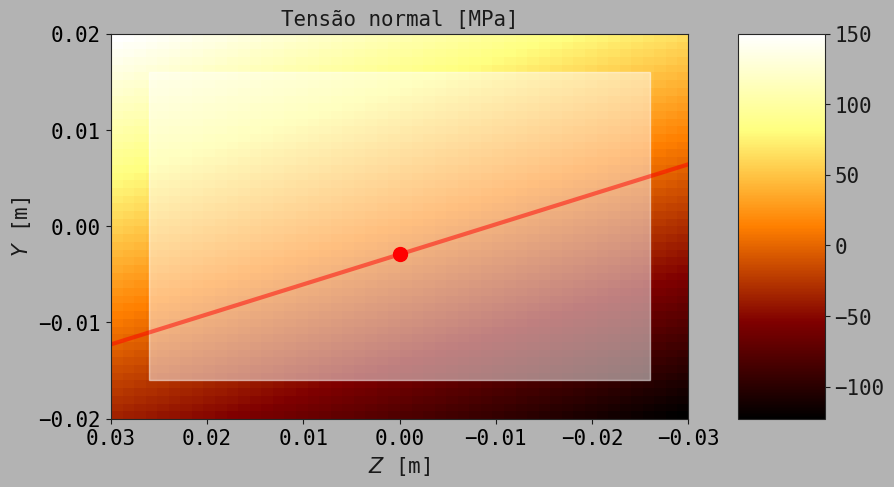

sig.max :: (0.02,0.03) :: 150.0 [MPa]
sig.min :: (-0.02,-0.03) :: -122.8 [MPa]


In [10]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

EqB = sigx - sigxx.subs({(q,Q)})
print(f'EqB = {EqB}')
sigxx = solve(EqB,sigx)[0]
print(f'sigxx(y,z)  = {sigxx*1e-6} [MPa]')

zsiz = np.linspace(d.tub_b/2,-d.tub_b/2)
ysiz = np.linspace(d.tub_h/2,-d.tub_h/2)
Z, Y = np.meshgrid(zsiz, ysiz)

def tensnormal(y2,z2):
    return sigxx.subs({(y,y2),(z,z2)}) #- eval_NAB/A - eval_MzAB/Iz*y + eval_MyAB/Iy*z

SxxMap = np.zeros(np.shape(Z))
for i in range(0,len(ysiz)):
    for j in range(0,len(zsiz)):
        SxxMap[i,j] = tensnormal(ysiz[i],zsiz[j])

yzfun = solve(sigxx,y)[0]
print(f'y = {yzfun} (recta geométrica do eixo neutro) [m]')
print(f'z = {solve(sigxx,z)[0]} (recta geométrica do eixo neutro) [m]')

zplo = zsiz
yplo = np.zeros(len(zplo))
for i in range(0,len(zplo)):
    yplo[i] = yzfun.subs(z,zplo[i])

fzp = 15
# Visualizacao u1(X1,X2,X3,t1)
fig = plt.figure(figsize=(10, 5))
ax  = plt.gca()
ttl = plt.title('Tensão normal [MPa]',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
im = ax.imshow(SxxMap*1e-6, extent=[d.tub_b/2, -d.tub_b/2, -d.tub_h/2,d.tub_h/2], cmap="afmhot")
ax.add_patch(Rectangle((-d.tub_b/2+d.tub_e, -d.tub_h/2+d.tub_e), d.tub_b-2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.5))
plt.plot(zplo,yplo,'r-',linewidth=3,alpha=0.5)
ax.plot(0,yzfun.subs(z,0),'or',markersize=10)
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="15%", pad=0.5)
cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
cbar.ax.tick_params(labelsize=fzp)
plt.show()

ymax_, zmax_ = d.tub_h/2, d.tub_b/2
sigmax_ = tensnormal(ymax_,zmax_)
print(f'sig.max :: ({ymax_},{zmax_}) :: {sigmax_*1e-6:.1f} [MPa]')

ymin_, zmin_ = -d.tub_h/2, -d.tub_b/2
sigmin_ = tensnormal(ymin_,zmin_)
print(f'sig.min :: ({ymin_},{zmin_}) :: {sigmin_*1e-6:.1f} [MPa]')

#### **c)** Calcule o tensor das tensões no ponto H referido ao sistema de eixos $xyz$.

##### Matriz do tensor das tensões no ponto H

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & \sigma_{yy} & \tau_{yz} \\
\tau_{xz} & \tau_{yz} & \sigma_{zz}
\end{bmatrix}
\end{equation*}

No problema de flexão em estudo apenas existem tensões normais segundo a direção $x~:~\sigma_{xx}=N/A~,~\sigma_{yy}=\sigma_{zz}=0$. Por outro lado, a secção em análise é normal ao eixo dos $x$, resultando

\begin{equation*}
[\sigma]_H =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & 0 & 0 \\
\tau_{xz} & 0 & 0
\end{bmatrix}
\end{equation*}

##### Tensão normal $\sigma_{xx}$ no ponto H

Análise da tensão normal, $\sigma_{xx}$, para o ponto H, com coordenadas $(y,z)$ = (0.02,0.015) [m]

In [11]:
yH, zH = d.tub_h/2, d.tub_b/2 - d.zHE
sigH = tensnormal(yH, zH)
print(f'sigxx.H({yH},{zH}) :: {sigH*1e-6:.2f} [MPa]')

sigxx.H(0.02,0.015) :: 128.26 [MPa]


####  Sistema de força-binário equivalente para os eforços associados a tensões de corte: $M_x, V_y, V_z, $

- Momento torsor em torno do eixo $x$, $M_x(T)$

Genericamente, o momento de uma força é obtido pelo produto vetorial entre o vetor posição, da distância do ponto de referência ao ponto de aplicação da força, e o próprio vetor da força. Só exercem momento segundo a direção $x$ as quantidades vetoriais que estão contidas num plano perpendicular ao eixo dos $x$. Neste caso, apenas a força $\vec{P}$ e $\vec{Q}$ exerce momento torsor segundo $x$.

\begin{equation*}
x-\mathrm{axis}:~
\circlearrowleft (+) ~ \Rightarrow ~
M_x = P \cdot h/2 + Q (z_{AB} + b/2)
\quad
(M_x \circlearrowleft)
\end{equation*}

com:

- $\vec{P} = P~\vec{k} ~\wedge~\vec{r}_{\vec{P}} = h/2~\vec{\jmath} \quad\therefore\quad  P (h/2)~\vec{\imath}$
- $\vec{Q} = -Q~\vec{\jmath} ~\wedge~~\vec{r}_{\vec{Q}} =(z_{AB} + b/2)~\vec{k} \quad\therefore\quad Q(z_{AB} + b/2)~\vec{\imath} $


In [12]:
Mx = d.Pz*d.tub_h/2 + Q*(d.zAB + d.tub_b/2)
print(f'Mx = {Mx:.1f} [N.m]')

Mx = 121.9 [N.m]


- Esforço transverso na direção $z$, $V_z$

\begin{equation*}
z:~\swarrow (+) ~ \Rightarrow ~
V_z = P
\end{equation*}

In [13]:
Vz = d.Pz
print(f'Vz = {Vz:.1f} [N]')

Vz = 1000.0 [N]



- Esforço transverso na direção $y$, $V_y$

\begin{equation*}
y:~\uparrow(+) ~ \Rightarrow ~
V_y = - Q
\quad\vee\quad
V_y = Q \downarrow 
\end{equation*}

In [14]:
Vy = -Q
print(f'Vy = {Vy:.1f} \u2261 {np.abs(Vy):.1f} \u2193   [N]')

Vy = -784.0 ≡ 784.0 ↓   [N]


#### Análise da tensões de corte devido aos esforços transversos e momento de torção

Importa salientar que, para a análise das componentes de tensão de corte originadas pelos esforços transversais $V_y$ e $V_z$, bem como pelo momento de torção, geralmente é mais conveniente considerar a resultante dos esforços internos como resultante do sistema de força-binário equivalente às forças externas

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P2/FBequi.png"
width="500">

##### Tensão de corte gerada pelo momento de torção

Análise da tensão de corte resultante do momento torsor, $\tau$, é dada por:

\begin{equation*}
T \equiv M_x = 2q A_0
\quad\therefore\quad
\tau_{xz}^{H} = \frac{q}{t} = \frac{|T|}{2A_0t}
\end{equation*}

- $A_0$ é a área interna definida pelo contorno da linha central da parede do perfil 
- $t$ é a espessura da parede do perfil tubular.

In [15]:
tor_A0 = (d.tub_h-d.tub_e)*(d.tub_b-d.tub_e)
print(f'tor_A0 = {d.tub_h-d.tub_e:.3f} x {d.tub_b-d.tub_e:.3f} = {tor_A0:.3e} [m²]')
tor_t = d.tub_e
print(f'tor_t = {tor_t:.3f} [m]')
tor_tau = np.abs(Mx)/2/tor_A0/tor_t
print(f'tor_tau = {tor_tau*1e-6:.2f} [MPa]')

tor_A0 = 0.036 x 0.056 = 2.016e-03 [m²]
tor_t = 0.004 [m]
tor_tau = 7.56 [MPa]


##### Análise da tensão de corte devida ao esforço transverso $V_z$

A componente da tensão de corte $\tau$ associada ao esforço transverso $V_z$ é dada por:

\begin{equation*}
\tau_{xz} = \frac{q}{t} = \left| \frac{V_zQ_y}{I_yt_b} \right|
\quad\wedge\quad
Q_y = A^\star\overline{z}
\end{equation*}

- $Q_y$ é o primeiro momento de área da região direita resultante do corte do perfil no ponto H segundo o eixo $y$ 
- $t_b$ é a espessura na segmento de corte.

Considerando o esforço transverso $V_z$, que é positivo ao longo do eixo $z$, o fluxo de corte começa no ponto à direita, a meio da secção ($Q_y = 0$). Este fluxo de corte propaga-se ao longo da parede fina, passando pela alma e atingindo os banzos superior e inferior, até chegar ao ponto $H$. No corte da secção no ponto $H$, resulta uma tensão de corte na direção $\tau_{xz}$.

Para o cálculo da tensão de corte no ponto $H$ devido ao esforço transverso $V_z$, é necessário avaliar 
$ Q_y(H)$. Para tal a área a considerar é a área a verde na figura, ou seja, a área definida desde o ponto inicial, onde $Q_y = 0$, até ao ponto $H$. Note-se que o primeiro momento de área também poderia ser calculado considerando a área a vermelho na figura.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P2/MSII_Au06_P2b.png"
width="500">

In [16]:
print('Considerando a área a verde:')
verde_A_retmaior = (d.tub_b - d.zHE)*d.tub_h/2
verde_zcent_retmaior = d.tub_b/2 - (d.tub_b - d.zHE)/2
verde_Q_retmaior = verde_A_retmaior*verde_zcent_retmaior
print(f'reg maior: z = {verde_zcent_retmaior:.4f} [m] | A = {verde_A_retmaior:.3e} [m²] | Q = {verde_Q_retmaior:.3e} [m³]')
verde_A_retmenor = (d.tub_b - d.zHE - d.tub_e)*(d.tub_h/2 - d.tub_e)
verde_zcent_retmenor = d.tub_b/2 - d.tub_e - (d.tub_b - d.zHE - d.tub_e)/2
verde_Q_retmenor = verde_A_retmenor*verde_zcent_retmenor
print(f'reg menor: z = {verde_zcent_retmenor:.4f} [m] | A = {verde_A_retmenor:.3e} [m²] | Q = {verde_Q_retmenor:.3e} [m³]')
verde_Qy = verde_Q_retmaior - verde_Q_retmenor
print(f'---\nQy = {verde_Qy:.3e} [m³]')

Considerando a área a verde:
reg maior: z = 0.0075 [m] | A = 9.000e-04 [m²] | Q = 6.750e-06 [m³]
reg menor: z = 0.0055 [m] | A = 6.560e-04 [m²] | Q = 3.608e-06 [m³]
---
Qy = 3.142e-06 [m³]


In [17]:
print('Alternadamente, considerando a área a vermelho:')
zretmaior = d.tub_b/2-d.zHE/2
Aretmaior = d.zHE*d.tub_h/2
Qretmaior = Aretmaior*zretmaior
print(f'reg maior: z = {zretmaior:.4f} [m] | A = {Aretmaior:.3e} [m²] | Q = {Qretmaior:.3e} [m³]')
zretmenor = d.tub_b/2-d.tub_e-(d.zHE-d.tub_e)/2
Aretmenor = (d.zHE-d.tub_e)*(d.tub_h-2*d.tub_e)/2
Qretmenor = Aretmenor*zretmenor
print(f'reg menor: z = {zretmenor:.4f} [m] | A = {Aretmenor:.3e} [m²] | Q = {Qretmenor:.3e} [m³]')
Qy = Qretmaior - Qretmenor
print(f'---\nQy = {Qy:.3e} [m³]')

Alternadamente, considerando a área a vermelho:
reg maior: z = 0.0225 [m] | A = 3.000e-04 [m²] | Q = 6.750e-06 [m³]
reg menor: z = 0.0205 [m] | A = 1.760e-04 [m²] | Q = 3.608e-06 [m³]
---
Qy = 3.142e-06 [m³]


In [18]:
Vz_tau = np.abs(Vz)*Qy/Iy/d.tub_e
print(f'Tau_Vz = ({np.abs(Vz):.1f})({Qy:.3e})/{Iy:.3e}/{d.tub_e} = {Vz_tau*1e-6:.2f} [MPa]')

Tau_Vz = (1000.0)(3.142e-06)/3.450e-07/0.004 = 2.28 [MPa]


##### Análise da tensão de corte devida ao esforço transverso $V_y$

A componente da tensão de corte $\tau$ associada ao esforço transverso $V_y$ é dada por:

\begin{equation*}
\tau_{xz} = \frac{q}{t} = \left| \frac{V_yQ_z}{I_zt_b} \right| 
= \left| \frac{V_y}{I_zt_b} (A^*\,\overline{y}) \right|
\end{equation*}

- $Q_z$ é o primeiro momento de área da região resultante do corte do perfil no ponto H segundo o eixo $z$ 
- $t_b$ é a espessura na segmento de corte.

De notar que o fluxo de corte $q = \tau t$ é apenas função de $Q_z$, assumindo $V_y, t_b$ e $I_z$ constantes. 

Como escolher a área de interesse para avaliar o momento de 1º ordem $Q_z$?

Para a secção de parede fina com esforço transverso $V_y$, deve-se seguir o fluxo de tensão a partir do ponto onde o esforço transverso é nulo, que neste caso corresponde ao ponto central do banzo superior do perfil da secção, uma vez que o esforço transverso $V_y$ é negativo (ver figura e Anexo). O fluxo de tensão aumentará gradualmente ao longo das paredes do banzo em ambas as direções (pode-se resolver o problema considerando a simetria em relação ao eixo $y$). Deve-se terminar na secção $H$ em análise. A componente da tensão de corte segue a direção normal à secção na parede fina. Portanto, no banzo superior, o ponto $H$ apresenta uma tensão de corte $\tau_{xz}$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P2/MSII_Au06_P2a.png"
width="500">

In [23]:
zcent = d.tub_h/2-d.tub_e/2
print(f'zcent = {zcent:.4f} [m]')
Aqz  = (d.tub_b/2-d.zHE)*d.tub_e
print(f'Aqz = ({(d.tub_b/2-d.zHE):.3f})({d.tub_e:.3f}) = {Aqz:.3e} [m²]')
Qz = Aqz*zcent
print(f'---\nQz = {Qz:.3e} [m³]')

zcent = 0.0180 [m]
Aqz = (0.015)(0.004) = 6.000e-05 [m²]
---
Qz = 1.080e-06 [m³]


In [20]:
Vy_tau = np.abs(Vy)*Qz/Iz/d.tub_e
print(f'\nTau_Vy = ({np.abs(Vy):.1f})({Qz:.3e})/{Iz:.3e}/{d.tub_e} = {Vy_tau*1e-6:.2f} [MPa]')


Tau_Vy = (784.0)(9.600e-07)/1.780e-07/0.004 = 1.06 [MPa]


- Tensor das tensões no ponto H, $[\sigma_H]$:

No banzo superior só vai have haver tensão de corte $\tau_{xz}$.

\begin{equation*}
\sigma_{xx}(y_H,z_H)
~\wedge~ \tau_{xy} = \tau_{yz} = 0
~\wedge~ \tau_{xz} = \frac{T}{2A_0t} + \frac{V_zQ_y}{I_yt_b} + \frac{V_yQ_z}{I_zt_b}
\end{equation*}

Pelo que o tensor das tensõe vem:

\begin{equation*}
[\sigma_H] =
\begin{bmatrix}
\sigma_{xx}(y_H,z_H) & 0 & \left(\displaystyle\frac{T}{2A_0t} + \frac{V_zQ_y}{I_yt_b} + \frac{V_yQ_z}{I_zt_b}\right)  \\
0 & 0 & 0 \\
\left(\displaystyle\frac{T}{2A_0t} + \frac{V_zQ_y}{I_yt_b} + \frac{V_yQ_z}{I_zt_b}\right)  & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [21]:
np.set_printoptions(precision=4)

def tenstens(s11,s12,s13,s22,s23,s33):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s23,s33]], np.float64)

ttH = tenstens(sigH,0,tor_tau+Vz_tau+Vy_tau,0,0,0)
print(f"ttH :: \n {np.array2string(ttH*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttH :: 
 [[128.26   0.00  10.89]
 [  0.00   0.00   0.00]
 [ 10.89   0.00   0.00]] [MPa]


## Anexo 

A equação $\tau = VQ / It$ pode ser utilizada para determinar as tensões de corte em vigas retangulares de parede fina, desde que os esforços sejam aplicadas num plano de simetria. A tensão de corte deve ser considerada perpendicular à superfície do elemento em análise, sendo determinado o valor da tensão de corte na direção tangente a essa superfície.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P2/Box-beam.png"
width="500">

[1] Beer, F. P., Johnston, E. R., DeWolf, J. T., & Mazurek, D. F. (2020). Mechanics of Materials (8th ed.). McGraw-Hill Education

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>